
# Stroke vs Healthy Classification — **Kinematics-Only** Replication of Romano et al. (2024, *Entropy* 26, 578)

This notebook replicates the **kinematic branch** of the paper as closely as the public
Van Criekinge et al. dataset allows: same 5 complexity metrics, same tolerance/embedding
parameters, same class-balancing + MRMR + nested-CV protocol, and the same 7 classifiers
with matched hyperparameter search ranges.




## 1. Setup — mount Drive, define paths

In [1]:
import os

# Double-check these exact strings against the right-hand Data panel in your notebook
STROKE_FILE  = '/kaggle/input/datasets/vanshisethi/gait-data/MAT_normalizedData_PostStrokeAdults_v27-02-23.xlsx'
HEALTHY_FILE = '/kaggle/input/datasets/vanshisethi/gait-data/MAT_normalizedData_AbleBodiedAdults_v06-03-23.xlsx'

# In Kaggle, /kaggle/working/ is the read-write directory for all generated files.
SAVE_DIR = '/kaggle/working/kinematic_results'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, 'figures'), exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, 'models'), exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, 'tables'), exist_ok=True)

print('Paths configured for Kaggle.')
print('All outputs will be saved under:', SAVE_DIR)

Paths configured for Kaggle.
All outputs will be saved under: /kaggle/working/kinematic_results


## 2. Install & import all required packages

In [2]:

!pip install -q antropy mrmr_selection tqdm openpyxl joblib

import time, warnings, json, joblib
import numpy as np
import pandas as pd
from scipy.signal import welch
from scipy.stats import ttest_ind
import antropy as ant
from tqdm.auto import tqdm

import mrmr
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              roc_auc_score, roc_curve, confusion_matrix)
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier, KernelDensity
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample
from scipy.stats import randint, loguniform
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.random.seed(42)
print("All libraries loaded.")


All libraries loaded.


## 3. Load kinematics only

Per the paper's protocol: **right side** for able-bodied controls (HC), **paretic
side** for stroke patients (SP) — *"entropy metrics were estimated for the right side
of the body in able-bodied subjects and for the paretic side in hemiparetic subjects"*
(Section 2.2).

In [3]:

KIN_COLS_HC = ["AnkleAngles", "KneeAngles", "HipAngles", "PelvisAngles"]
KIN_COLS_SP = ["Pside_AnkleAngles", "Pside_KneeAngles", "Pside_HipAngles", "Pside_PelvisAngles"]
JOINT_NAMES = ["Ankle", "Knee", "Hip", "Pelvis"]

def load_kinematics_only(path, kin_cols, group_label):
    subjects, skipped = {}, []
    xl = pd.ExcelFile(path)
    for sheet in xl.sheet_names:
        if 'readme' in sheet.lower():
            continue
        df = xl.parse(sheet, header=0)
        if df.empty:
            skipped.append(f'{sheet} (empty)')
            continue
        cols_lower = {str(c).lower().strip(): c for c in df.columns}
        actual_cols = [cols_lower.get(c.lower()) for c in kin_cols if c.lower() in cols_lower]
        if len(actual_cols) != len(kin_cols):
            skipped.append(f'{sheet} (missing columns)')
            continue
        sub_df = df[actual_cols].copy()
        sub_df.columns = JOINT_NAMES
        subjects[sheet] = sub_df.reset_index(drop=True)
    print(f"[{group_label}] loaded {len(subjects)} subjects, skipped {len(skipped)}: {skipped}")
    return subjects

hc_kin = load_kinematics_only(HEALTHY_FILE, KIN_COLS_HC, 'HC')
sp_kin = load_kinematics_only(STROKE_FILE,  KIN_COLS_SP, 'SP')

assert len(hc_kin) == 138, f"Expected 138 HC subjects, got {len(hc_kin)}"
assert len(sp_kin) == 50,  f"Expected 50 SP subjects, got {len(sp_kin)}"


[HC] loaded 138 subjects, skipped 0: []
[SP] loaded 50 subjects, skipped 0: []


### 3.1 Data-quality check (length / missingness) — sanity check before feature extraction

In [4]:

def qc_report(subj_dict, label):
    lens = pd.Series({sid: len(df) for sid, df in subj_dict.items()})
    total_nan = sum(df.isna().sum().sum() for df in subj_dict.values())
    print(f"[{label}] N={len(subj_dict)}  length range=({lens.min()},{lens.max()})  total NaN cells={total_nan}")

qc_report(hc_kin, 'HC')
qc_report(sp_kin, 'SP')


[HC] N=138  length range=(1001,1001)  total NaN cells=0
[SP] N=50  length range=(1001,1001)  total NaN cells=0


## 4. Entropy / complexity metrics (Section 2.3 of the paper)

Implemented exactly as specified:
- **ApEn** — `m=2`, `r=20% of signal SD` (Section 2.3.1)
- **SampEn** — `m=2`, `r=20% of signal SD` (Section 2.3.2)
- **FuzzyEn** — `m=2`, `r=20% of signal SD`, exponential membership `n=2` (Section 2.3.3)
- **SpEn** — computed from the Welch PSD; since it is a distribution, the paper reduces
  it to its first four statistical moments (mean, std, skewness, kurtosis) — *"only for
  this metric the first four moments of a distribution were extracted"* (Section 2.3.4)

No multiscale decomposition and no Conditional Entropy here


In [5]:

def calculate_spectral_moments(signal, fs=1000.0):
    """4 statistical moments (mean, std, skewness, kurtosis) of the power spectral density."""
    signal = np.asarray(signal, dtype=float)
    if len(signal) < 8:
        return 0.0, 0.0, 0.0, 0.0
    freqs, psd = welch(signal, fs=fs, nperseg=min(256, len(signal)))
    total_power = np.sum(psd)
    if total_power <= 0 or not np.isfinite(total_power):
        return 0.0, 0.0, 0.0, 0.0
    p_i = psd / total_power
    mean_freq = np.sum(freqs * p_i)
    var_freq = np.sum(p_i * (freqs - mean_freq) ** 2)
    std_freq = np.sqrt(var_freq)
    if std_freq > 0:
        skew_freq = np.sum(p_i * ((freqs - mean_freq) / std_freq) ** 3)
        kurt_freq = np.sum(p_i * ((freqs - mean_freq) / std_freq) ** 4) - 3.0
    else:
        skew_freq, kurt_freq = 0.0, 0.0
    return mean_freq, std_freq, skew_freq, kurt_freq


def fuzzy_entropy(signal, m=2, r=0.2, n=2):
    """Fuzzy Entropy with exponential membership function u(x) = exp(-(d/r)^n)."""
    signal = np.asarray(signal, dtype=float)
    N = len(signal)
    if N <= m + 1:
        return 0.0

    def _phi(m_dim):
        x = np.array([signal[i:i + m_dim] for i in range(N - m_dim + 1)])
        x_base = x - np.mean(x, axis=1, keepdims=True)          # remove local baseline
        dist = np.max(np.abs(x_base[:, None, :] - x_base[None, :, :]), axis=-1)  # Chebyshev
        np.fill_diagonal(dist, np.inf)                          # exclude self-match
        sim = np.exp(-((dist / r) ** n))
        np.fill_diagonal(sim, 0.0)
        return np.sum(sim) / ((N - m_dim + 1) * (N - m_dim))

    phi_m, phi_m1 = _phi(m), _phi(m + 1)
    if phi_m == 0 or phi_m1 == 0:
        return 0.0
    return -np.log(phi_m1 / phi_m)


def extract_kinematic_features(subj_dict, label_val, group_name):
    """ApEn, SampEn, FuzzyEn, SpEn(4 moments) for each of the 4 joints -> 28 features/subject."""
    rows = []
    for sid, df in tqdm(subj_dict.items(), desc=f"Extracting {group_name}"):
        row = {'Subject_ID': f"{group_name}_{sid}", 'Label': label_val}
        for joint in JOINT_NAMES:
            sig = df[joint].dropna().values
            sig_std = np.std(sig)
            r_val = 0.2 * sig_std if sig_std > 0 else 1e-6

            row[f"{joint}_ApEn"]    = ant.app_entropy(sig, order=2, metric='chebyshev')
            row[f"{joint}_SampEn"]  = ant.sample_entropy(sig, order=2, metric='chebyshev')
            row[f"{joint}_FuzzyEn"] = fuzzy_entropy(sig, m=2, r=r_val, n=2)

            sp_mean, sp_std, sp_skew, sp_kurt = calculate_spectral_moments(sig, fs=1000.0)
            row[f"{joint}_SpEn_Mean"] = sp_mean
            row[f"{joint}_SpEn_Std"]  = sp_std
            row[f"{joint}_SpEn_Skew"] = sp_skew
            row[f"{joint}_SpEn_Kurt"] = sp_kurt
        rows.append(row)
    return pd.DataFrame(rows)

df_hc = extract_kinematic_features(hc_kin, label_val=0, group_name="HC")
df_sp = extract_kinematic_features(sp_kin, label_val=1, group_name="SP")

df_features = pd.concat([df_hc, df_sp], ignore_index=True)
print(f"\nFeature extraction complete. Shape: {df_features.shape}  (28 features + ID + Label)")
df_features.head()


Extracting HC:   0%|          | 0/138 [00:00<?, ?it/s]

Extracting SP:   0%|          | 0/50 [00:00<?, ?it/s]


Feature extraction complete. Shape: (188, 30)  (28 features + ID + Label)


,Subject_ID,Label,Ankle_ApEn,Ankle_SampEn,Ankle_FuzzyEn,Ankle_SpEn_Mean,Ankle_SpEn_Std,Ankle_SpEn_Skew,Ankle_SpEn_Kurt,Knee_ApEn,...,Hip_SpEn_Std,Hip_SpEn_Skew,Hip_SpEn_Kurt,Pelvis_ApEn,Pelvis_SampEn,Pelvis_FuzzyEn,Pelvis_SpEn_Mean,Pelvis_SpEn_Std,Pelvis_SpEn_Skew,Pelvis_SpEn_Kurt
0,HC_Sub01,0,0.030560,0.027381,0.005679,3.616143,2.098929,0.071154,1.566501,0.024464,...,1.441423,0.917015,14.779125,0.033589,0.028089,0.007115,3.609938,2.086222,0.146954,2.260591
1,HC_Sub02,0,0.032028,0.032020,0.005937,3.514070,2.217202,0.121414,1.106437,0.022487,...,1.377275,1.266280,18.015975,0.032440,0.024634,0.006210,3.648499,1.929917,0.170581,4.027216
2,HC_Sub03,0,0.029778,0.027992,0.005246,3.759282,1.982095,0.094901,2.523908,0.023131,...,1.414551,1.046284,16.487371,0.067972,0.065852,0.019319,3.904606,2.345189,0.282023,3.880900
3,HC_Sub04,0,0.031160,0.029827,0.005548,3.619527,2.107522,0.066998,1.653019,0.024670,...,1.447810,0.886522,14.677849,0.036357,0.035241,0.006295,4.027613,1.825640,0.334660,4.642577
4,HC_Sub05,0,0.028159,0.026612,0.004577,3.681812,1.987034,0.090480,2.540978,0.021473,...,1.399730,1.144704,17.442996,0.052980,0.044578,0.014666,3.983912,2.557554,0.190084,0.717129


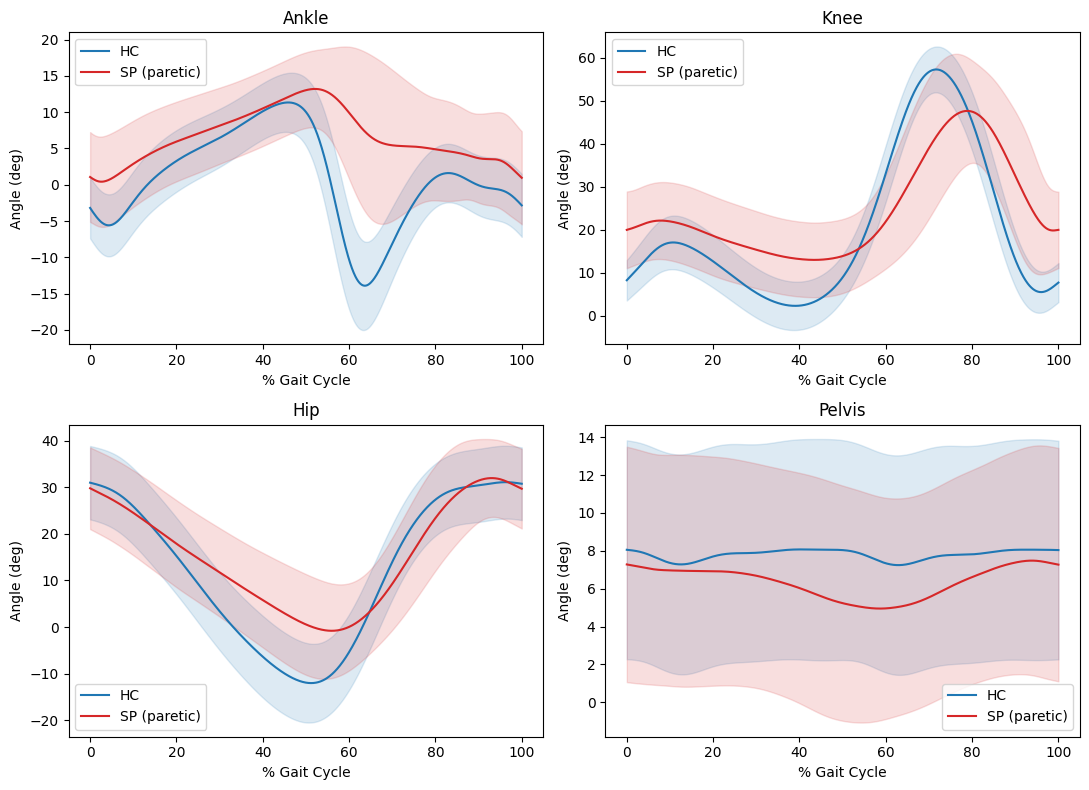

In [7]:
import matplotlib.pyplot as plt

def mean_curve(subj_dict, joint, n_points=1000):
    """Resample every subject's curve to n_points and average, for plotting only."""
    curves = []
    for df in subj_dict.values():
        sig = df[joint].dropna().values
        if len(sig) < 10:
            continue
        x_old = np.linspace(0, 1, len(sig))
        x_new = np.linspace(0, 1, n_points)
        curves.append(np.interp(x_new, x_old, sig))
    curves = np.array(curves)
    return curves.mean(axis=0), curves.std(axis=0)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, joint in zip(axes.ravel(), JOINT_NAMES):
    hc_mean, hc_std = mean_curve(hc_kin, joint)
    sp_mean, sp_std = mean_curve(sp_kin, joint)
    pct = np.linspace(0, 100, len(hc_mean))

    ax.plot(pct, hc_mean, label='HC', color='tab:blue')
    ax.fill_between(pct, hc_mean - hc_std, hc_mean + hc_std, alpha=0.15, color='tab:blue')
    ax.plot(pct, sp_mean, label='SP (paretic)', color='tab:red')
    ax.fill_between(pct, sp_mean - sp_std, sp_mean + sp_std, alpha=0.15, color='tab:red')

    ax.set_title(joint)
    ax.set_xlabel('% Gait Cycle')
    ax.set_ylabel('Angle (deg)')
    ax.legend()

plt.tight_layout()
plt.savefig('hc_vs_sp_mean_curves.png', dpi=150)
plt.show()

### 4.1 Sanitize (no leakage — median imputation is later done *inside* each CV fold, this only removes inf)

In [8]:

X_kin = df_features.drop(columns=['Subject_ID', 'Label']).replace([np.inf, -np.inf], np.nan)
y_all = df_features['Label'].reset_index(drop=True)
X_kin = X_kin.reset_index(drop=True)
print(f"X shape: {X_kin.shape}  |  HC={sum(y_all==0)}  SP={sum(y_all==1)}")


X shape: (188, 28)  |  HC=138  SP=50


## 5. Classifiers & hyperparameter grids (Section 2.4, Table of optimized hyperparameters)

Same 7 models as the paper, with search ranges matched to what is reported:

| Model | Paper hyperparameters searched |
|---|---|
| Coarse Tree | MinLeaf 1–39, MaxNumSplits 1–77, GDI split criterion |
| Logistic Regression | Lasso regularization strength, 30 learning cycles |
| Kernel Naive Bayes | kernel bandwidth *h* |
| Cubic SVM | Box constraint *C*, kernel scale *γ* (cubic/degree-3 polynomial kernel) |
| Fine KNN | *k* neighbors, Euclidean distance, uniform weights |
| Bagged Trees | NumTrees 5–100 (step 10), MinLeaf 1–39, MaxNumSplits 1–77, 30 learning cycles |
| Medium NN | 1–3 layers, 1–300 units/layer, ReLU, regularization 1.27e-7–1.28e3 |


In [9]:

# --- Kernel Naive Bayes (MATLAB fitcnb 'DistributionNames','kernel' equivalent) ---
class KDEClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, bandwidth=1.0, kernel='gaussian'):
        self.bandwidth = bandwidth
        self.kernel = kernel

    def fit(self, X, y):
        X = np.asarray(X)
        self.classes_ = np.unique(y)
        self.models_, self.priors_ = {}, {}
        for c in self.classes_:
            X_c = X[y == c]
            self.priors_[c] = len(X_c) / len(X)
            self.models_[c] = [KernelDensity(bandwidth=self.bandwidth, kernel=self.kernel).fit(X_c[:, i:i+1])
                                for i in range(X.shape[1])]
        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        log_probs = np.zeros((X.shape[0], len(self.classes_)))
        for idx, c in enumerate(self.classes_):
            log_p = np.sum([m.score_samples(X[:, i:i+1]) for i, m in enumerate(self.models_[c])], axis=0)
            log_probs[:, idx] = log_p + np.log(self.priors_[c])
        probs = np.exp(log_probs - np.max(log_probs, axis=1, keepdims=True))
        return probs / np.sum(probs, axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


# --- Random architecture sampler for the Medium NN (1-3 layers, 1-300 units/layer) ---
class NNArchitectureDist:
    def __init__(self, min_layers=1, max_layers=3, min_units=1, max_units=300):
        self.min_layers, self.max_layers = min_layers, max_layers
        self.min_units, self.max_units = min_units, max_units

    def rvs(self, random_state=None):
        rng = np.random.RandomState(random_state) if not isinstance(random_state, np.random.RandomState) else random_state
        n_layers = rng.randint(self.min_layers, self.max_layers + 1)
        return tuple(int(rng.randint(self.min_units, self.max_units + 1)) for _ in range(n_layers))


models_and_grids = {
    "Coarse Tree": {
        "model": Pipeline([('imputer', SimpleImputer(strategy='median')),
                            ('model', DecisionTreeClassifier(criterion='gini', random_state=42))]),
        "params": {"model__min_samples_leaf": randint(1, 40),
                   "model__max_leaf_nodes": randint(2, 78)}
    },
    "Logistic Regression": {
        "model": Pipeline([('imputer', SimpleImputer(strategy='median')),
                            ('scaler', StandardScaler()),
                            ('model', LogisticRegression(penalty='l1', solver='liblinear',
                                                          max_iter=1000, random_state=42))]),
        "params": {"model__C": loguniform(1e-6, 10.0)}
    },
    "Kernel Naive Bayes": {
        "model": Pipeline([('imputer', SimpleImputer(strategy='median')),
                            ('scaler', StandardScaler()),
                            ('model', KDEClassifier())]),
        "params": {"model__bandwidth": loguniform(0.05, 5.0)}
    },
    "Cubic SVM": {
        "model": Pipeline([('imputer', SimpleImputer(strategy='median')),
                            ('scaler', StandardScaler()),
                            ('model', SVC(kernel='poly', degree=3, coef0=1.0,
                                          probability=True, random_state=42))]),
        "params": {"model__C": loguniform(1, 1500), "model__gamma": loguniform(1e-3, 10.0)}
    },
    "Fine KNN": {
        "model": Pipeline([('imputer', SimpleImputer(strategy='median')),
                            ('scaler', StandardScaler()),
                            ('model', KNeighborsClassifier(metric='euclidean', weights='uniform'))]),
        "params": {"model__n_neighbors": randint(1, 10)}
    },
    "Bagged Trees": {
        "model": Pipeline([('imputer', SimpleImputer(strategy='median')),
                            ('model', RandomForestClassifier(random_state=42, n_jobs=-1))]),
        "params": {"model__n_estimators": np.arange(5, 105, 10),
                   "model__min_samples_leaf": randint(1, 40),
                   "model__max_leaf_nodes": randint(2, 78)}
    },
    "Medium NN": {
        "model": Pipeline([('imputer', SimpleImputer(strategy='median')),
                            ('scaler', StandardScaler()),
                            ('model', MLPClassifier(activation='relu', max_iter=1000, random_state=42))]),
        "params": {"model__hidden_layer_sizes": NNArchitectureDist(1, 3, 1, 300),
                   "model__alpha": loguniform(1.27e-7, 1.28e3)}
    }
}
print("7 classifiers configured:", list(models_and_grids.keys()))


7 classifiers configured: ['Coarse Tree', 'Logistic Regression', 'Kernel Naive Bayes', 'Cubic SVM', 'Fine KNN', 'Bagged Trees', 'Medium NN']


## 6. MRMR feature selection + Nested Cross-Validation engine (Section 2.4)

Mirrors the paper's protocol exactly:
- **Class balancing**: 50 SP vs. 50 randomly-resampled HC, repeated for `N_ITERATIONS`
  (paper used 1000 to "explore all possible sample combinations")
- **Outer loop**: 10-fold nested CV for unbiased test performance
- **Feature selection**: MRMR, top **10** features, re-computed **inside every training
  fold only** (zero leakage — MRMR never sees the test fold)
- **Inner loop**: hyperparameter search (RandomizedSearchCV) validated with its own CV
- Metrics collected: Accuracy, Precision, Recall, AUC (mean ± std), plus out-of-fold
  predictions to build the confusion matrix / ROC curve for the best model.

⏱️ **Runtime note:** `N_ITERATIONS=1000` (as in the paper) is very expensive — it means
1000 × 10 = 10,000 outer folds × inner random search per classifier. Start with
`N_ITERATIONS=20` to validate the pipeline runs end-to-end, then raise to `1000` for the
final paper-matching run (leave it running unattended / use a GPU-less long session).

In [10]:

def apply_mrmr_selection(X_train, y_train, X_test, k=10):
    imputer = SimpleImputer(strategy='median')
    X_tr_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    k_eff = min(k, X_tr_imp.shape[1])
    selected_cols = mrmr.pandas.mrmr_classif(X=X_tr_imp, y=y_train, K=k_eff,
                                              return_scores=False, show_progress=False)
    return X_train[selected_cols], X_test[selected_cols], selected_cols


def evaluate_models_aligned(X, y, dataset_name, n_iterations=20, n_splits=10, n_iter_search=30, k_features=10):
    results = []
    oof_store = {name: {'y_true': [], 'y_pred': [], 'y_prob': []} for name in models_and_grids}
    feature_votes = {name: {} for name in models_and_grids}

    hc_indices = y[y == 0].index
    sp_indices = y[y == 1].index

    for name, config in tqdm(models_and_grids.items(), desc=f"{dataset_name} — models"):
        fold_metrics = {'acc': [], 'prec': [], 'rec': [], 'auc': []}

        for iter_i in tqdm(range(1, n_iterations + 1), desc=name, leave=False):
            hc_sampled_ix = resample(hc_indices, n_samples=len(sp_indices), replace=False, random_state=iter_i * 42)
            balanced_ix = np.concatenate([hc_sampled_ix, sp_indices])

            X_bal = X.loc[balanced_ix].reset_index(drop=True)
            y_bal = y.loc[balanced_ix].reset_index(drop=True)

            outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=iter_i)

            for train_ix, test_ix in outer_cv.split(X_bal, y_bal):
                X_train, X_test = X_bal.iloc[train_ix], X_bal.iloc[test_ix]
                y_train, y_test = y_bal.iloc[train_ix], y_bal.iloc[test_ix]

                X_train_sel, X_test_sel, sel_cols = apply_mrmr_selection(X_train, y_train, X_test, k=k_features)
                for c in sel_cols:
                    feature_votes[name][c] = feature_votes[name].get(c, 0) + 1

                inner_cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=1, random_state=42)
                search = RandomizedSearchCV(
                    estimator=config['model'], param_distributions=config['params'],
                    n_iter=n_iter_search, cv=inner_cv, scoring='accuracy',
                    n_jobs=-1, random_state=42 + iter_i
                )
                search.fit(X_train_sel, y_train)
                best_model = search.best_estimator_

                y_pred = best_model.predict(X_test_sel)
                y_prob = best_model.predict_proba(X_test_sel)[:, 1] if hasattr(best_model, "predict_proba") else None

                fold_metrics['acc'].append(accuracy_score(y_test, y_pred))
                fold_metrics['prec'].append(precision_score(y_test, y_pred, zero_division=0))
                fold_metrics['rec'].append(recall_score(y_test, y_pred, zero_division=0))
                fold_metrics['auc'].append(roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan)

                oof_store[name]['y_true'].extend(y_test.tolist())
                oof_store[name]['y_pred'].extend(y_pred.tolist())
                oof_store[name]['y_prob'].extend(y_prob.tolist() if y_prob is not None else [np.nan] * len(y_test))

        results.append({
            'Feature Set': dataset_name,
            'Model': name,
            'Accuracy (%)': f"{np.mean(fold_metrics['acc'])*100:.2f} ± {np.std(fold_metrics['acc'])*100:.2f}",
            'Precision (%)': f"{np.mean(fold_metrics['prec'])*100:.2f} ± {np.std(fold_metrics['prec'])*100:.2f}",
            'Recall (%)': f"{np.mean(fold_metrics['rec'])*100:.2f} ± {np.std(fold_metrics['rec'])*100:.2f}",
            'AUC': f"{np.nanmean(fold_metrics['auc']):.4f} ± {np.nanstd(fold_metrics['auc']):.4f}",
            '_mean_acc': np.mean(fold_metrics['acc']),
        })
        print(f"  {name:<22} acc={np.mean(fold_metrics['acc'])*100:6.2f}%  "
              f"auc={np.nanmean(fold_metrics['auc']):.3f}")

    return pd.DataFrame(results), oof_store, feature_votes


## 7. Run the evaluation

In [11]:

# Start small to validate the pipeline, then set to 1000 to exactly match the paper's protocol.
N_ITERATIONS = 20      # <-- set to 1000 for the final paper-matching run
N_SPLITS = 10           # outer nested-CV folds (matches paper: "10-fold nCV")
N_ITER_SEARCH = 30      # RandomizedSearchCV budget per inner fold
K_FEATURES = 10         # MRMR-selected features (matches paper's ~10 selected kinematic features)

results_kinematics, oof_kinematics, feature_votes_kinematics = evaluate_models_aligned(
    X_kin, y_all, "Kinematic",
    n_iterations=N_ITERATIONS, n_splits=N_SPLITS,
    n_iter_search=N_ITER_SEARCH, k_features=K_FEATURES
)

results_kinematics_display = results_kinematics.drop(columns=['_mean_acc'])
results_kinematics_display


Kinematic — models:   0%|          | 0/7 [00:00<?, ?it/s]

Coarse Tree:   0%|          | 0/20 [00:00<?, ?it/s]

  Coarse Tree            acc= 88.20%  auc=0.900


Logistic Regression:   0%|          | 0/20 [00:00<?, ?it/s]

  Logistic Regression    acc= 92.30%  auc=0.958


...

Bagged Trees:   0%|          | 0/20 [00:00<?, ?it/s]

  Bagged Trees           acc= 91.65%  auc=0.972


Medium NN:   0%|          | 0/20 [00:00<?, ?it/s]

  Medium NN              acc= 92.30%  auc=0.951


,Feature Set,Model,Accuracy (%),Precision (%),Recall (%),AUC
0,Kinematic,Coarse Tree,88.20 ± 10.71,92.26 ± 11.49,84.90 ± 17.61,0.8999 ± 0.1030
1,Kinematic,Logistic Regression,92.30 ± 8.76,97.37 ± 7.35,87.60 ± 15.56,0.9576 ± 0.0722
2,Kinematic,Kernel Naive Bayes,91.55 ± 8.72,97.29 ± 6.98,85.90 ± 15.47,0.9387 ± 0.0877
3,Kinematic,Cubic SVM,92.30 ± 8.29,97.15 ± 7.10,87.70 ± 14.65,0.9594 ± 0.0641
4,Kinematic,Fine KNN,90.00 ± 8.77,98.43 ± 5.83,81.50 ± 16.24,0.9200 ± 0.0880
5,Kinematic,Bagged Trees,91.65 ± 8.23,95.89 ± 8.77,88.00 ± 13.27,0.9717 ± 0.0536
6,Kinematic,Medium NN,92.30 ± 8.70,96.76 ± 7.78,88.00 ± 14.70,0.9506 ± 0.0771


## 8. Best model — confusion matrix & ROC curve (paper-style Figure 1A)

Built from the pooled **out-of-fold** predictions across all balanced iterations / outer
folds, exactly as the paper's confusion matrices summarize aggregated nested-CV test
predictions.

Best kinematic model: Logistic Regression


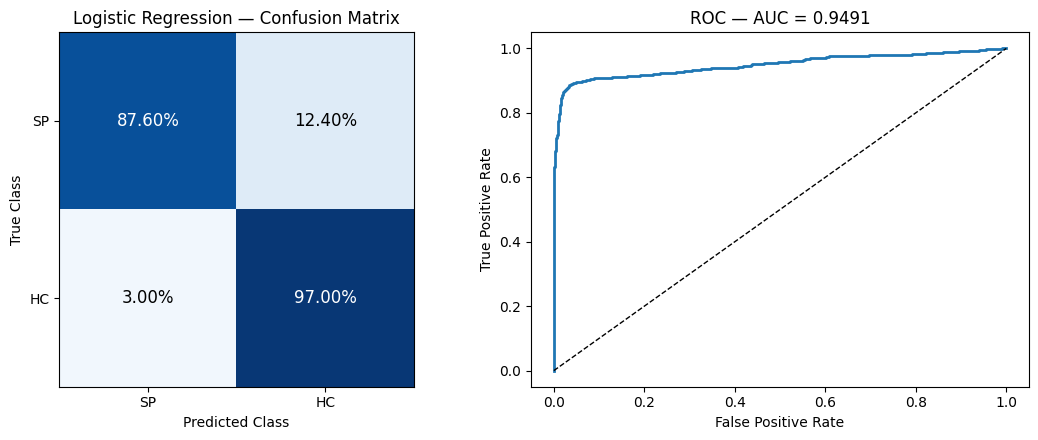

In [12]:

best_name = results_kinematics.loc[results_kinematics['_mean_acc'].idxmax(), 'Model']
print(f"Best kinematic model: {best_name}")

yt = np.array(oof_kinematics[best_name]['y_true'])
yp = np.array(oof_kinematics[best_name]['y_pred'])
ypr = np.array(oof_kinematics[best_name]['y_prob'])

cm = confusion_matrix(yt, yp, labels=[1, 0])  # order SP, HC to mirror paper layout
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

im = axes[0].imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['SP', 'HC'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['SP', 'HC'])
axes[0].set_xlabel('Predicted Class'); axes[0].set_ylabel('True Class')
axes[0].set_title(f'{best_name} — Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f"{cm_pct[i, j]:.2f}%", ha='center', va='center',
                     color='white' if cm_pct[i, j] > 50 else 'black', fontsize=12)

fpr, tpr, _ = roc_curve(yt, ypr)
auc_val = roc_auc_score(yt, ypr)
axes[1].plot(fpr, tpr, color='tab:blue', lw=2)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC — AUC = {auc_val:.4f}')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'figures', 'best_model_confusion_roc.png'), dpi=300, bbox_inches='tight')
plt.show()


## 9. MRMR-selected features + unpaired t-test (paper-style Table 2)

The paper reports the features MRMR most consistently selected across CV folds, then
tests each with an unpaired t-test (SP vs HC), flagging `p < 0.05` as significant.

In [13]:

# Most frequently selected features for the best model, across all folds/iterations
votes = pd.Series(feature_votes_kinematics[best_name]).sort_values(ascending=False)
top_features = votes.head(K_FEATURES).index.tolist()
print("Most frequently MRMR-selected kinematic features:")
print(votes.head(K_FEATURES))

rows = []
for feat in top_features:
    hc_vals = X_kin.loc[y_all == 0, feat].dropna()
    sp_vals = X_kin.loc[y_all == 1, feat].dropna()
    t_stat, p_val = ttest_ind(sp_vals, hc_vals, equal_var=False)
    rows.append({'Metric': feat, 't statistic': round(t_stat, 3), 'p value': p_val,
                 'Significant (p<0.05)': 'Yes' if p_val < 0.05 else 'No'})

table2_style = pd.DataFrame(rows)
table2_style
# Save the table to your outputs directory as a CSV
table2_style.to_csv(os.path.join(SAVE_DIR, 'tables', f'top_{K_FEATURES}_features_ttest.csv'), index=False)

Most frequently MRMR-selected kinematic features:
Pelvis_ApEn         200
Hip_SampEn          200
Pelvis_FuzzyEn      200
Pelvis_SpEn_Kurt    200
Pelvis_SpEn_Std     194
Pelvis_SampEn       190
Hip_ApEn            178
Hip_FuzzyEn         153
Ankle_SpEn_Mean     146
Hip_SpEn_Kurt       138
dtype: int64


## 10. Final results table (paper Table 1 format, kinematic block only)

Save results to disk for reporting / comparison against the published Table 1.

In [14]:

results_kinematics_display.to_csv(os.path.join(SAVE_DIR, 'tables', 'kinematic_results_table1_style.csv'), index=False)
table2_style.to_csv(os.path.join(SAVE_DIR, 'tables', 'kinematic_selected_features_ttest.csv'), index=False)
print("Saved to", os.path.join(SAVE_DIR, 'tables'))
results_kinematics_display


Saved to /kaggle/working/kinematic_results/tables


,Feature Set,Model,Accuracy (%),Precision (%),Recall (%),AUC
0,Kinematic,Coarse Tree,88.20 ± 10.71,92.26 ± 11.49,84.90 ± 17.61,0.8999 ± 0.1030
1,Kinematic,Logistic Regression,92.30 ± 8.76,97.37 ± 7.35,87.60 ± 15.56,0.9576 ± 0.0722
2,Kinematic,Kernel Naive Bayes,91.55 ± 8.72,97.29 ± 6.98,85.90 ± 15.47,0.9387 ± 0.0877
3,Kinematic,Cubic SVM,92.30 ± 8.29,97.15 ± 7.10,87.70 ± 14.65,0.9594 ± 0.0641
4,Kinematic,Fine KNN,90.00 ± 8.77,98.43 ± 5.83,81.50 ± 16.24,0.9200 ± 0.0880
5,Kinematic,Bagged Trees,91.65 ± 8.23,95.89 ± 8.77,88.00 ± 13.27,0.9717 ± 0.0536
6,Kinematic,Medium NN,92.30 ± 8.70,96.76 ± 7.78,88.00 ± 14.70,0.9506 ± 0.0771


# Part B — Publication-Quality Figures & Full Model Persistence

Everything below builds on the objects already computed above
(`results_kinematics`, `oof_kinematics`, `feature_votes_kinematics`, `X_kin`, `y_all`,
`models_and_grids`). Re-run Part A first (or re-run the whole notebook) before this part.

This section adds the kind of evidence a reviewer looks for in a methods paper:
1. A metrics comparison figure across all 7 classifiers, with error bars
2. Fold-wise accuracy distributions (variance, not just the mean)
3. All-model ROC overlay
4. A full confusion-matrix grid
5. MRMR feature-selection stability (how consistently each feature was chosen)
6. Group-separation plots for the top features, with significance stars
7. A pairwise DeLong test between every pair of classifiers' ROC curves (same logic the
   paper uses in Table 3, applied here across your 7 models instead of feature sets)
8. Final production models — trained once, saved to Drive, reloadable without retraining


## 11. Metrics comparison bar chart (mean ± std across all folds/iterations)

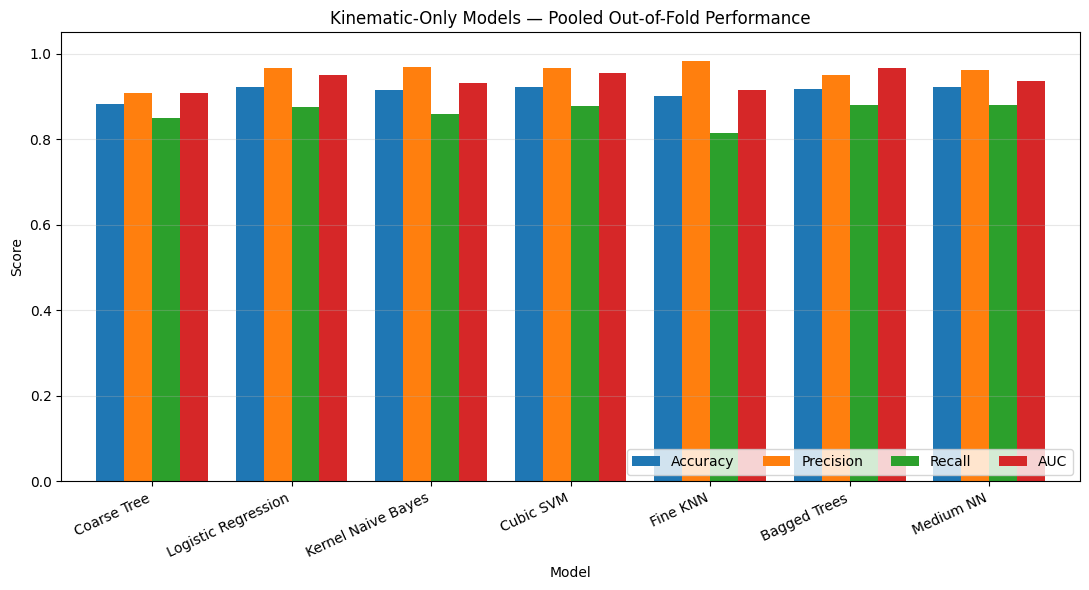

In [15]:

metric_rows = []
for name in models_and_grids:
    yt_ = np.array(oof_kinematics[name]['y_true'])
    yp_ = np.array(oof_kinematics[name]['y_pred'])
    ypr_ = np.array(oof_kinematics[name]['y_prob'])
    metric_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(yt_, yp_),
        'Precision': precision_score(yt_, yp_, zero_division=0),
        'Recall': recall_score(yt_, yp_, zero_division=0),
        'AUC': roc_auc_score(yt_, ypr_) if not np.isnan(ypr_).all() else np.nan,
    })
metrics_df = pd.DataFrame(metric_rows).set_index('Model')

fig, ax = plt.subplots(figsize=(11, 6))
metrics_df[['Accuracy', 'Precision', 'Recall', 'AUC']].plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Score')
ax.set_title('Kinematic-Only Models — Pooled Out-of-Fold Performance')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', ncol=4)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'figures', 'metrics_comparison_bar.png'), dpi=300, bbox_inches='tight')
plt.show()
metrics_df
# Save the exact numerical metrics to your tables directory
metrics_df.to_csv(os.path.join(SAVE_DIR, 'tables', 'pooled_oof_metrics_comparison.csv'))

## 12. Fold-wise accuracy distributions (boxplot) — shows robustness, not just the mean

Raw fold accuracies saved to CSV.


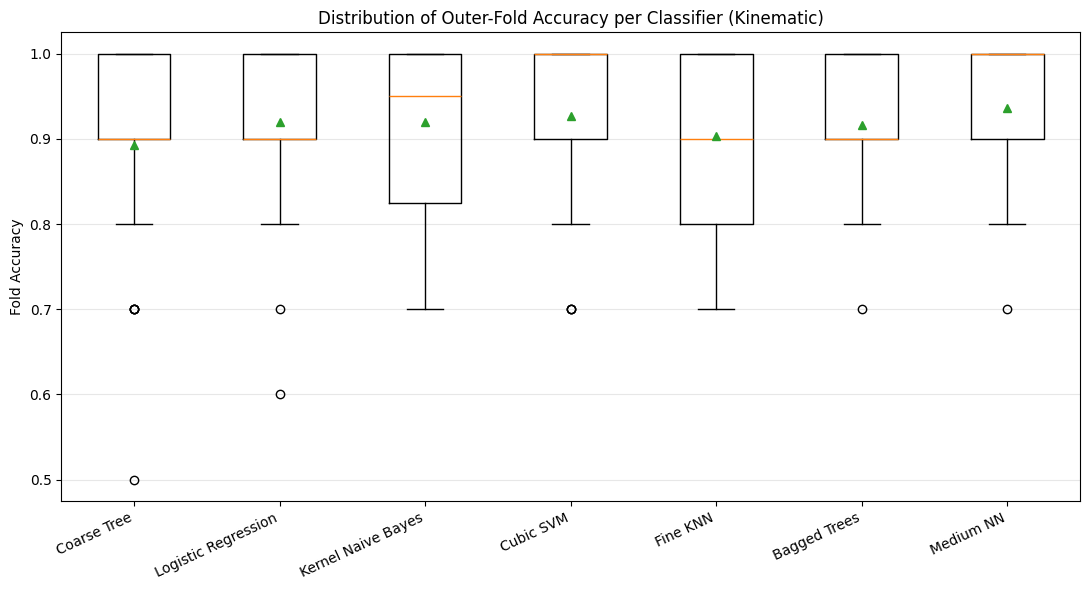

In [16]:
from tqdm.notebook import tqdm  # Clean visual progress bar for Kaggle
from sklearn.utils import resample
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score

def collect_fold_accuracies(X, y, n_iterations, n_splits, n_iter_search, k_features):
    acc_by_model = {name: [] for name in models_and_grids}
    hc_indices = y[y == 0].index
    sp_indices = y[y == 1].index
    
    for name, config in tqdm(models_and_grids.items(), desc="Collecting fold accuracies"):
        for iter_i in range(1, n_iterations + 1):
            hc_sampled_ix = resample(hc_indices, n_samples=len(sp_indices), replace=False, random_state=iter_i * 42)
            balanced_ix = np.concatenate([hc_sampled_ix, sp_indices])
            X_bal = X.loc[balanced_ix].reset_index(drop=True)
            y_bal = y.loc[balanced_ix].reset_index(drop=True)
            
            outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=iter_i)
            for train_ix, test_ix in outer_cv.split(X_bal, y_bal):
                X_train, X_test = X_bal.iloc[train_ix], X_bal.iloc[test_ix]
                y_train, y_test = y_bal.iloc[train_ix], y_bal.iloc[test_ix]
                
                X_train_sel, X_test_sel, _ = apply_mrmr_selection(X_train, y_train, X_test, k=k_features)
                inner_cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=1, random_state=42)
                
                search = RandomizedSearchCV(
                    config['model'], config['params'], n_iter=n_iter_search,
                    cv=inner_cv, scoring='accuracy', n_jobs=-1, random_state=42 + iter_i
                )
                search.fit(X_train_sel, y_train)
                acc_by_model[name].append(accuracy_score(y_test, search.best_estimator_.predict(X_test_sel)))
                
    return acc_by_model

# NOTE: reuses N_ITERATIONS/N_SPLITS from Section 7.
QUICK = True
acc_by_model = collect_fold_accuracies(
    X_kin, y_all,
    n_iterations=(3 if QUICK else N_ITERATIONS), n_splits=N_SPLITS,
    n_iter_search=N_ITER_SEARCH, k_features=K_FEATURES
)

# SAVE THE RAW DATA (So you never have to re-run this slow loop just for numbers!)
acc_df = pd.DataFrame(acc_by_model)
acc_df.to_csv(os.path.join(SAVE_DIR, 'tables', 'fold_accuracies_raw.csv'), index=False)
print("Raw fold accuracies saved to CSV.")

# Plot and save boxplot
fig, ax = plt.subplots(figsize=(11, 6))
ax.boxplot([acc_by_model[m] for m in models_and_grids], labels=list(models_and_grids.keys()), showmeans=True)
ax.set_ylabel('Fold Accuracy')
ax.set_title('Distribution of Outer-Fold Accuracy per Classifier (Kinematic)')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'figures', 'accuracy_boxplot.png'), dpi=300, bbox_inches='tight')
plt.show()

## 13. All-model ROC overlay & full confusion-matrix grid

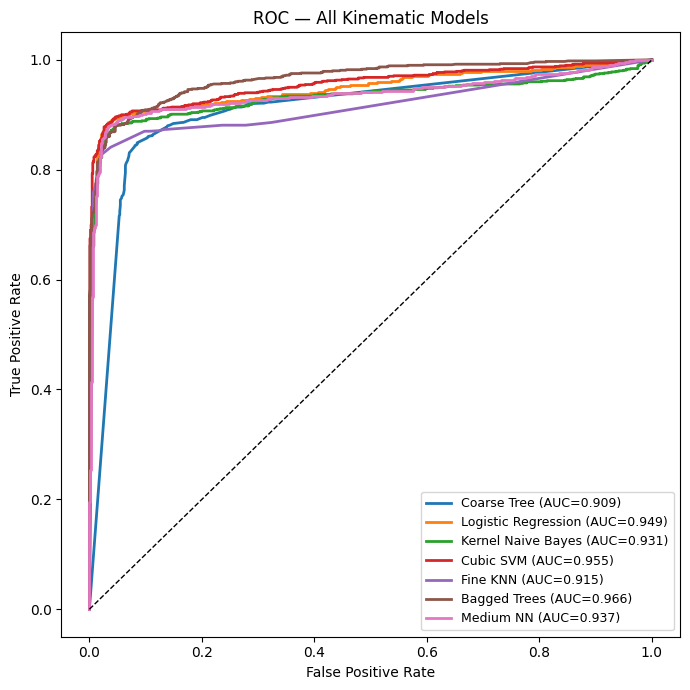

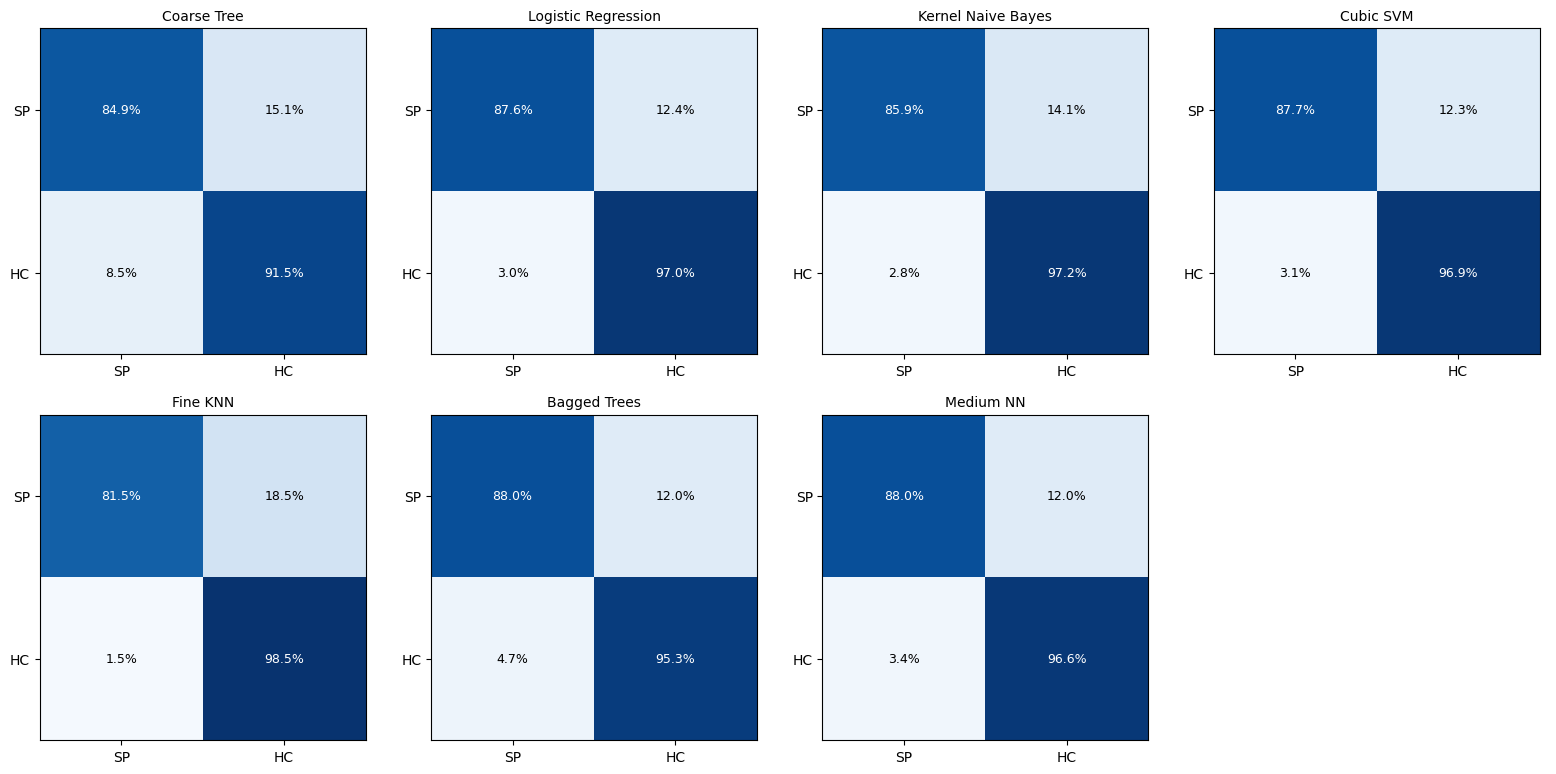

In [17]:

fig, ax = plt.subplots(figsize=(7, 7))
for name in models_and_grids:
    yt_ = np.array(oof_kinematics[name]['y_true'])
    ypr_ = np.array(oof_kinematics[name]['y_prob'])
    if np.isnan(ypr_).all():
        continue
    fpr, tpr, _ = roc_curve(yt_, ypr_)
    auc_val = roc_auc_score(yt_, ypr_)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_val:.3f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC — All Kinematic Models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'figures', 'roc_all_models.png'), dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, name in zip(axes.ravel(), models_and_grids):
    yt_ = np.array(oof_kinematics[name]['y_true'])
    yp_ = np.array(oof_kinematics[name]['y_pred'])
    cm_ = confusion_matrix(yt_, yp_, labels=[1, 0])
    cm_pct_ = cm_ / cm_.sum(axis=1, keepdims=True) * 100
    ax.imshow(cm_pct_, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['SP', 'HC'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['SP', 'HC'])
    ax.set_title(name, fontsize=10)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm_pct_[i, j]:.1f}%", ha='center', va='center',
                     color='white' if cm_pct_[i, j] > 50 else 'black', fontsize=9)
for ax in axes.ravel()[len(models_and_grids):]:
    ax.axis('off')
plt.tight_layout(pad=2.0, w_pad=1.5, h_pad=2.0)
plt.savefig(os.path.join(SAVE_DIR, 'figures', 'confusion_matrix_grid.png'), dpi=300, bbox_inches='tight')
plt.show()


## 14. MRMR feature-selection stability

A feature selected in nearly every fold is a far stronger, more reproducible biomarker
than one selected occasionally by chance — exactly the robustness evidence reviewers
look for.

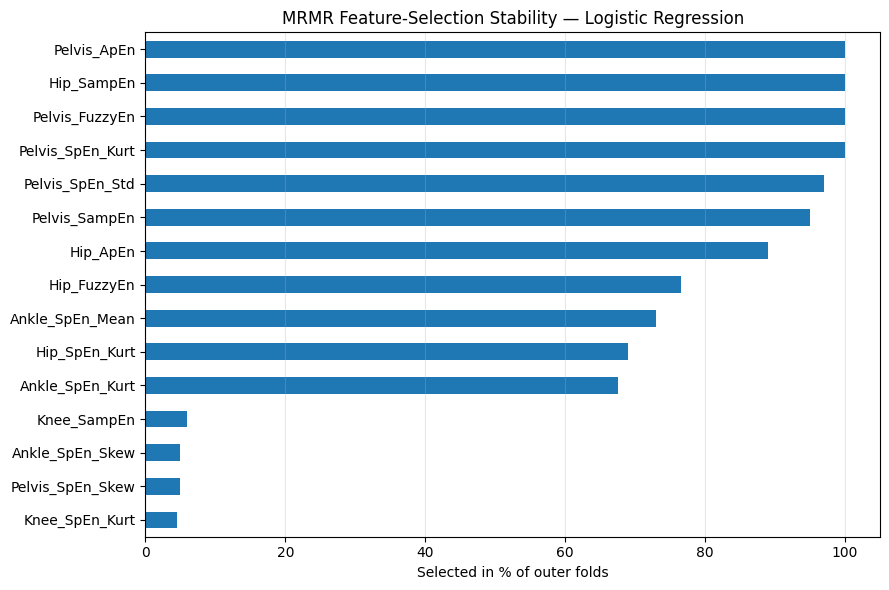

Feature stability table saved to CSV.


Pelvis_ApEn         100.0
Hip_SampEn          100.0
Pelvis_FuzzyEn      100.0
Pelvis_SpEn_Kurt    100.0
Pelvis_SpEn_Std      97.0
Pelvis_SampEn        95.0
Hip_ApEn             89.0
Hip_FuzzyEn          76.5
Ankle_SpEn_Mean      73.0
Hip_SpEn_Kurt        69.0
Ankle_SpEn_Kurt      67.5
Knee_SampEn           6.0
Ankle_SpEn_Skew       5.0
Pelvis_SpEn_Skew      5.0
Knee_SpEn_Kurt        4.5
dtype: float64

In [18]:

votes_all = pd.Series(feature_votes_kinematics[best_name]).sort_values(ascending=False)
n_total_folds = N_ITERATIONS * N_SPLITS
stability_pct = (votes_all / n_total_folds * 100).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
stability_pct.iloc[::-1].plot(kind='barh', ax=ax, color='tab:blue')
ax.set_xlabel('Selected in % of outer folds')
ax.set_title(f'MRMR Feature-Selection Stability — {best_name}')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'figures', 'feature_selection_stability.png'), dpi=300, bbox_inches='tight')
plt.show()
# Convert the top 15 (or all) stability percentages to a DataFrame and save to disk
stability_df = (votes_all / n_total_folds * 100).reset_index()
stability_df.columns = ['Feature', 'Selection_Percentage']
stability_df.to_csv(os.path.join(SAVE_DIR, 'tables', f'feature_stability_top15_{best_name}.csv'), index=False)
print("Feature stability table saved to CSV.")
stability_pct


## 15. Group-separation plots for the top features (SP vs HC, with significance stars)

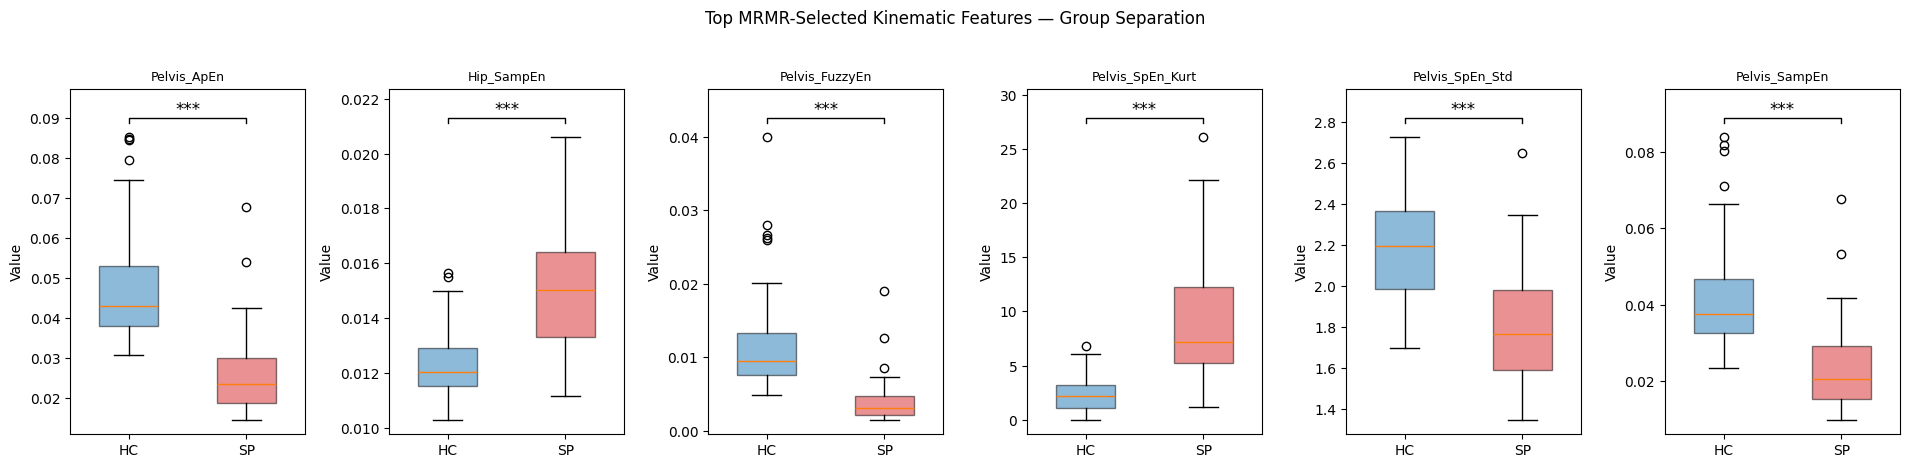

In [19]:

def p_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

top_n_plot = min(6, len(top_features))
fig, axes = plt.subplots(1, top_n_plot, figsize=(3.2 * top_n_plot, 4.5))
if top_n_plot == 1:
    axes = [axes]

for ax, feat in zip(axes, top_features[:top_n_plot]):
    hc_vals = X_kin.loc[y_all == 0, feat].dropna()
    sp_vals = X_kin.loc[y_all == 1, feat].dropna()
    t_stat, p_val = ttest_ind(sp_vals, hc_vals, equal_var=False)

    bp = ax.boxplot([hc_vals, sp_vals], labels=['HC', 'SP'], patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], ['tab:blue', 'tab:red']):
        patch.set_facecolor(color); patch.set_alpha(0.5)

    y_max = max(hc_vals.max(), sp_vals.max())
    y_range = max(hc_vals.max(), sp_vals.max()) - min(hc_vals.min(), sp_vals.min())
    y_range = y_range if y_range > 0 else 1.0
    bar_y = y_max + 0.05 * y_range
    ax.plot([1, 1, 2, 2], [bar_y, bar_y + 0.02*y_range, bar_y + 0.02*y_range, bar_y], color='black', lw=1)
    ax.text(1.5, bar_y + 0.03*y_range, p_to_stars(p_val), ha='center', fontsize=12)
    # Add 10% headroom to the top of the y-axis so stars are never clipped
    ax.set_ylim(bottom=min(hc_vals.min(), sp_vals.min()) - 0.05*y_range, top=bar_y + 0.12*y_range)

    ax.set_title(feat, fontsize=9)
    ax.set_ylabel('Value')

plt.suptitle('Top MRMR-Selected Kinematic Features — Group Separation', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'figures', 'feature_group_separation.png'), dpi=300, bbox_inches='tight')
plt.show()


## 16. Pairwise DeLong test between classifiers (statistical rigor, like the paper's Table 3)

The paper uses the DeLong test to prove AUC differences between feature sets are
statistically significant, not noise. Here it is applied **between classifiers** (same
feature set) to show which models are *significantly* better than which.

DeLong p-value matrix saved to CSV.


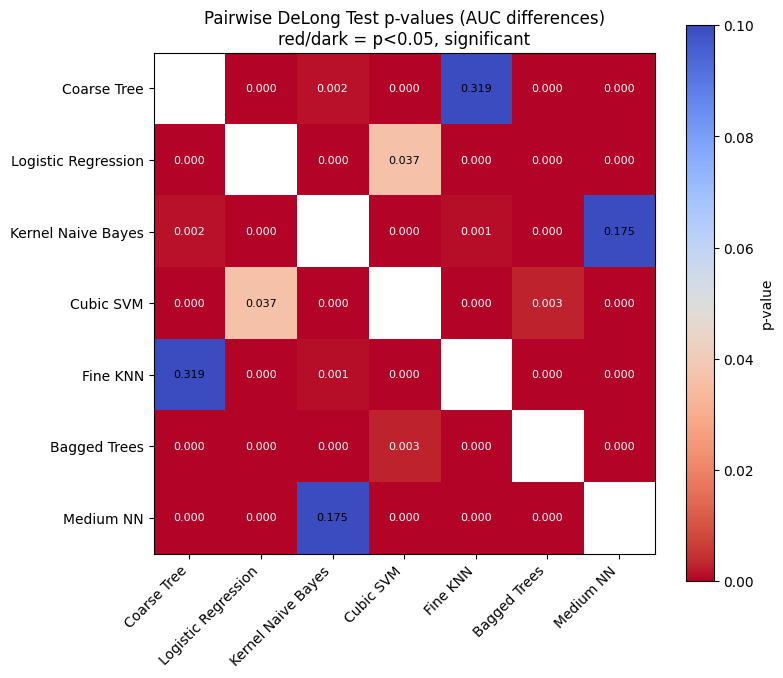

,Coarse Tree,Logistic Regression,Kernel Naive Bayes,Cubic SVM,Fine KNN,Bagged Trees,Medium NN
Coarse Tree,NaN,1.475640e-10,1.514919e-03,2.819966e-13,3.186399e-01,0.000000e+00,8.778335e-06
Logistic Regression,1.475640e-10,NaN,1.164395e-05,3.669049e-02,1.937117e-12,2.744113e-05,3.321229e-04
Kernel Naive Bayes,1.514919e-03,1.164395e-05,NaN,4.206495e-07,1.082619e-03,8.199819e-11,1.749660e-01
Cubic SVM,2.819966e-13,3.669049e-02,4.206495e-07,NaN,2.220446e-16,2.752364e-03,1.572887e-06
Fine KNN,3.186399e-01,1.937117e-12,1.082619e-03,2.220446e-16,NaN,0.000000e+00,3.678294e-06
Bagged Trees,0.000000e+00,2.744113e-05,8.199819e-11,2.752364e-03,0.000000e+00,NaN,3.370220e-10
Medium NN,8.778335e-06,3.321229e-04,1.749660e-01,1.572887e-06,3.678294e-06,3.370220e-10,NaN


In [20]:
def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def _fast_delong(y_true, y_score):
    """AUC and its variance via the DeLong (1988) structural-components method."""
    order = np.argsort(-y_true, kind='mergesort')
    y_true_s, y_score_s = y_true[order], y_score[order]
    m = int(np.sum(y_true_s))
    n = len(y_true_s) - m
    pos, neg = y_score_s[:m], y_score_s[m:]

    tx = _compute_midrank(pos)
    ty = _compute_midrank(neg)
    tz = _compute_midrank(y_score_s)

    v01 = (tz[:m] - tx) / n
    v10 = 1.0 - (tz[m:] - ty) / m
    auc = np.mean(v01)

    s01 = np.var(v01, ddof=1) / m
    s10 = np.var(v10, ddof=1) / n
    var_auc = s01 + s10
    return auc, var_auc, v01, v10

def delong_pairwise_p(y_true, score_a, score_b):
    """Two-sided p-value comparing two correlated ROC AUCs on the same samples."""
    y_true = np.asarray(y_true); score_a = np.asarray(score_a); score_b = np.asarray(score_b)
    auc_a, var_a, v01_a, v10_a = _fast_delong(y_true, score_a)
    auc_b, var_b, v01_b, v10_b = _fast_delong(y_true, score_b)
    m, n = int(np.sum(y_true)), int(len(y_true) - np.sum(y_true))
    cov01 = np.cov(v01_a, v01_b, ddof=1)[0, 1] / m
    cov10 = np.cov(v10_a, v10_b, ddof=1)[0, 1] / n
    cov = cov01 + cov10
    var_diff = var_a + var_b - 2 * cov
    if var_diff <= 0:
        return auc_a, auc_b, np.nan, np.nan
    z = (auc_a - auc_b) / np.sqrt(var_diff)
    from scipy.stats import norm
    p = 2 * (1 - norm.cdf(abs(z)))
    return auc_a, auc_b, z, p

model_names = list(models_and_grids.keys())
pval_matrix = pd.DataFrame(np.nan, index=model_names, columns=model_names)

min_len = min(len(oof_kinematics[m]['y_true']) for m in model_names)
for i, m1 in enumerate(model_names):
    for j, m2 in enumerate(model_names):
        if j <= i:
            continue
        yt1 = np.array(oof_kinematics[m1]['y_true'])[:min_len]
        yt2 = np.array(oof_kinematics[m2]['y_true'])[:min_len]
        if not np.array_equal(yt1, yt2):
            continue
        s1 = np.array(oof_kinematics[m1]['y_prob'])[:min_len]
        s2 = np.array(oof_kinematics[m2]['y_prob'])[:min_len]
        if np.isnan(s1).any() or np.isnan(s2).any():
            continue
        _, _, _, p = delong_pairwise_p(yt1, s1, s2)
        pval_matrix.loc[m1, m2] = p
        pval_matrix.loc[m2, m1] = p

# Save exact p-values to disk
pval_matrix.to_csv(os.path.join(SAVE_DIR, 'tables', 'delong_pairwise_pvalues.csv'))
print("DeLong p-value matrix saved to CSV.")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(pval_matrix.astype(float), cmap='coolwarm_r', vmin=0, vmax=0.1)
ax.set_xticks(range(len(model_names))); ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_yticks(range(len(model_names))); ax.set_yticklabels(model_names)

for i in range(len(model_names)):
    for j in range(len(model_names)):
        val = pval_matrix.iloc[i, j]
        if not np.isnan(val):
            # Dynamic text contrast: white on dark red (p < 0.02), black otherwise
            text_color = 'white' if val < 0.02 else 'black'
            ax.text(j, i, f"{val:.3f}", ha='center', va='center', color=text_color, fontsize=8)

ax.set_title('Pairwise DeLong Test p-values (AUC differences)\nred/dark = p<0.05, significant')
plt.colorbar(im, ax=ax, label='p-value')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'figures', 'delong_pairwise_pvalues.png'), dpi=300, bbox_inches='tight')
plt.show()

pval_matrix

## 17. Train & save FINAL production models — do this ONCE, never retrain again

The nested-CV loop above exists purely to give an **unbiased performance estimate**
(what the Table 1-style numbers mean). Models trained inside those folds are throwaway —
each was fit on a different slice of a different balanced resample, so no single one is
"the" model.

For a **deployable/reusable model**, the correct procedure is: run one more, final round
of MRMR + hyperparameter search on a representative balanced dataset, then fit each
classifier on all of it. That final pipeline is what gets saved to Drive.

In [21]:
import os
import json
import joblib
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm  # Clean visual progress bar for Kaggle
from sklearn.utils import resample
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV
import mrmr.pandas

FINAL_SEED = 2024
hc_indices = y_all[y_all == 0].index
sp_indices = y_all[y_all == 1].index
hc_final_ix = resample(hc_indices, n_samples=len(sp_indices), replace=False, random_state=FINAL_SEED)
final_ix = np.concatenate([hc_final_ix, sp_indices])
X_final = X_kin.loc[final_ix].reset_index(drop=True)
y_final = y_all.loc[final_ix].reset_index(drop=True)

imputer_final = SimpleImputer(strategy='median')
X_final_imp = pd.DataFrame(imputer_final.fit_transform(X_final), columns=X_final.columns)
final_selected_features = mrmr.pandas.mrmr_classif(
    X=X_final_imp, y=y_final, K=K_FEATURES, return_scores=False, show_progress=False
)
print("Final production feature set:", final_selected_features)

X_final_sel = X_final[final_selected_features]

trained_bundles = {}
for name, config in tqdm(models_and_grids.items(), desc="Training final production models"):
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=FINAL_SEED)
    search = RandomizedSearchCV(config['model'], config['params'], n_iter=50, cv=cv,
                                scoring='accuracy', n_jobs=-1, random_state=FINAL_SEED)
    search.fit(X_final_sel, y_final)
    final_model = search.best_estimator_

    bundle = {
        'model_name': name,
        'pipeline': final_model,
        'selected_features': final_selected_features,
        'best_params': search.best_params_,
        'cv_best_score': search.best_score_,
        'joint_names': JOINT_NAMES,
        'trained_on': f"{len(X_final_sel)} balanced samples ({len(sp_indices)} SP + {len(hc_final_ix)} HC)",
    }
    trained_bundles[name] = bundle

    model_path = os.path.join(SAVE_DIR, 'models', f"{name.replace(' ', '_')}.joblib")
    joblib.dump(bundle, model_path)
    print(f"  saved: {model_path}  (CV accuracy={search.best_score_:.4f})")

joblib.dump(trained_bundles, os.path.join(SAVE_DIR, 'models', 'ALL_MODELS_BUNDLE.joblib'))

metadata = {
    'paper': 'Romano et al. 2024, Entropy 26(7):578',
    'feature_set': 'Kinematic (sagittal joint angles substitute for calcaneus XYZ)',
    'joints_used': JOINT_NAMES,
    'entropy_metrics': ['ApEn', 'SampEn', 'FuzzyEn', 'SpEn_Mean', 'SpEn_Std', 'SpEn_Skew', 'SpEn_Kurt'],
    'k_features_selected': K_FEATURES,
    'final_selected_features': final_selected_features,
    'models_saved': list(trained_bundles.keys()),
    'n_iterations_evaluation': N_ITERATIONS,
    'n_splits_evaluation': N_SPLITS,
}
with open(os.path.join(SAVE_DIR, 'models', 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print("\nAll production models + metadata saved to:", os.path.join(SAVE_DIR, 'models'))

Final production feature set: ['Pelvis_ApEn', 'Hip_SampEn', 'Pelvis_FuzzyEn', 'Pelvis_SpEn_Std', 'Hip_SpEn_Kurt', 'Pelvis_SpEn_Kurt', 'Pelvis_SampEn', 'Hip_ApEn', 'Ankle_SpEn_Mean', 'Hip_FuzzyEn']


Training final production models:   0%|          | 0/7 [00:00<?, ?it/s]

  saved: /kaggle/working/kinematic_results/models/Coarse_Tree.joblib  (CV accuracy=0.9150)
  saved: /kaggle/working/kinematic_results/models/Logistic_Regression.joblib  (CV accuracy=0.9400)
  saved: /kaggle/working/kinematic_results/models/Kernel_Naive_Bayes.joblib  (CV accuracy=0.9300)
  saved: /kaggle/working/kinematic_results/models/Cubic_SVM.joblib  (CV accuracy=0.9550)
  saved: /kaggle/working/kinematic_results/models/Fine_KNN.joblib  (CV accuracy=0.9250)
  saved: /kaggle/working/kinematic_results/models/Bagged_Trees.joblib  (CV accuracy=0.9450)
  saved: /kaggle/working/kinematic_results/models/Medium_NN.joblib  (CV accuracy=0.9450)

All production models + metadata saved to: /kaggle/working/kinematic_results/models


## 18. Reload saved models later — **no retraining required**

Run this cell (after mounting Drive) in any future session to get every trained model
back immediately.

In [22]:
import os
import joblib

# Point to your Kaggle working directory where the bundle was just saved
SAVE_DIR = '/kaggle/working/kinematic_results'
all_models = joblib.load(
    os.path.join(SAVE_DIR, 'models', 'ALL_MODELS_BUNDLE.joblib')
)

print('Loaded models:', list(all_models.keys()))
for name, bundle in all_models.items():
  print(
      f"  {name:<22} CV accuracy={bundle['cv_best_score']:.4f} "
      f" features={bundle['selected_features']}"
  )


Loaded models: ['Coarse Tree', 'Logistic Regression', 'Kernel Naive Bayes', 'Cubic SVM', 'Fine KNN', 'Bagged Trees', 'Medium NN']
  Coarse Tree            CV accuracy=0.9150  features=['Pelvis_ApEn', 'Hip_SampEn', 'Pelvis_FuzzyEn', 'Pelvis_SpEn_Std', 'Hip_SpEn_Kurt', 'Pelvis_SpEn_Kurt', 'Pelvis_SampEn', 'Hip_ApEn', 'Ankle_SpEn_Mean', 'Hip_FuzzyEn']
  Logistic Regression    CV accuracy=0.9400  features=['Pelvis_ApEn', 'Hip_SampEn', 'Pelvis_FuzzyEn', 'Pelvis_SpEn_Std', 'Hip_SpEn_Kurt', 'Pelvis_SpEn_Kurt', 'Pelvis_SampEn', 'Hip_ApEn', 'Ankle_SpEn_Mean', 'Hip_FuzzyEn']
  Kernel Naive Bayes     CV accuracy=0.9300  features=['Pelvis_ApEn', 'Hip_SampEn', 'Pelvis_FuzzyEn', 'Pelvis_SpEn_Std', 'Hip_SpEn_Kurt', 'Pelvis_SpEn_Kurt', 'Pelvis_SampEn', 'Hip_ApEn', 'Ankle_SpEn_Mean', 'Hip_FuzzyEn']
  Cubic SVM              CV accuracy=0.9550  features=['Pelvis_ApEn', 'Hip_SampEn', 'Pelvis_FuzzyEn', 'Pelvis_SpEn_Std', 'Hip_SpEn_Kurt', 'Pelvis_SpEn_Kurt', 'Pelvis_SampEn', 'Hip_ApEn', 'Ankle_SpEn_Mean', '